# 📊 End-to-End Sales Forecasting & Demand Intelligence System

## Final Internship Assessment

### Submitted By:
**Satya Sindhu Konda**

---

## Project Overview

This project develops an end-to-end Sales Forecasting and Demand Intelligence System using historical retail sales data. The system performs comprehensive exploratory data analysis, time series decomposition, sales forecasting using multiple models (SARIMA, Prophet, and XGBoost), anomaly detection, product demand segmentation, and deployment through an interactive Streamlit dashboard.

The objective is to assist business stakeholders in making informed inventory planning and demand forecasting decisions.

In [5]:
#Install required libraries
!pip install prophet xgboost --quiet

In [6]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Time Series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Machine Learning
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Forecasting
from prophet import Prophet
from xgboost import XGBRegressor

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot Settings
plt.style.use('ggplot')
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
# ==========================================================
# Load Datasets
# ==========================================================

sales_df = pd.read_csv("train.csv")
games_df = pd.read_csv("vgsales.csv")

print("="*60)
print("Sales Dataset Shape :", sales_df.shape)
print("Video Games Dataset Shape :", games_df.shape)
print("="*60)

sales_df.head()

Sales Dataset Shape : (9800, 18)
Video Games Dataset Shape : (16598, 11)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
# Dataset Information
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
sales_df.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [10]:
missing = sales_df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

print(missing)

Postal Code    11
dtype: int64


In [11]:
print("Duplicate Records :",sales_df.duplicated().sum())

Duplicate Records : 0


In [12]:
# Convert Date Columns

sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    dayfirst=True
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    dayfirst=True
)

print("✅ Date Conversion Completed Successfully!")

✅ Date Conversion Completed Successfully!


In [13]:
# ==========================================================
# Feature Engineering
# ==========================================================

# Date Features
sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Month Name"] = sales_df["Order Date"].dt.month_name()
sales_df["Week"] = sales_df["Order Date"].dt.isocalendar().week
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter
sales_df["Day of Week"] = sales_df["Order Date"].dt.day_name()

# Season Function
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

sales_df["Season"] = sales_df["Month"].apply(get_season)

# Shipping Duration
sales_df["Shipping Days"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days

print("✅ Feature Engineering Completed Successfully!")

sales_df.head()

✅ Feature Engineering Completed Successfully!


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Quarter,Day of Week,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,4,Wednesday,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,4,Wednesday,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,2,Monday,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,4,Tuesday,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,4,Tuesday,Autumn,7


In [14]:
sales_df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Month Name', 'Week',
       'Quarter', 'Day of Week', 'Season', 'Shipping Days'],
      dtype='object')

# 📊 Task 1: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand sales trends, customer behavior, product performance, regional sales distribution, and seasonal patterns. The insights obtained from this analysis will guide the forecasting models and business recommendations in later stages of the project.

### Business Questions
1. Which product category generates the highest revenue?
2. Which region has the most consistent sales growth?
3. What is the average shipping time across regions?
4. Are there seasonal sales patterns?

In [15]:
print("="*60)
print("Dataset Shape :", sales_df.shape)
print("="*60)

sales_df.head()

Dataset Shape : (9800, 26)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Quarter,Day of Week,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,4,Wednesday,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,4,Wednesday,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,2,Monday,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,4,Tuesday,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,4,Tuesday,Autumn,7


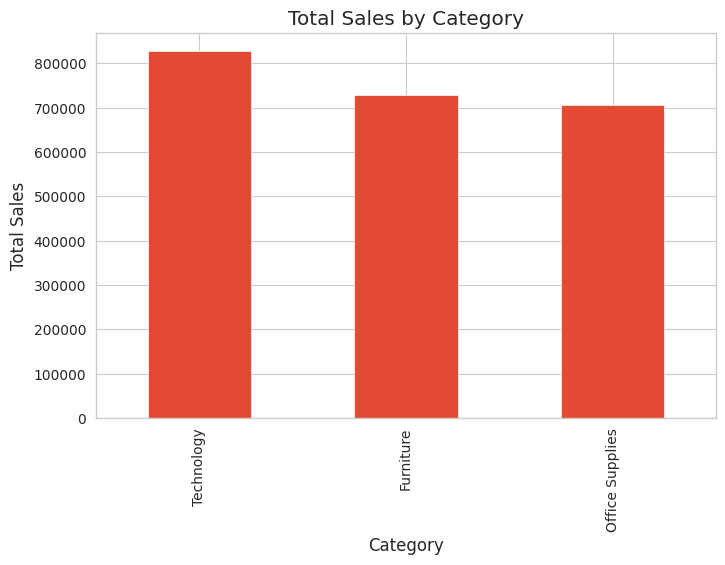

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


In [16]:
category_sales = (
    sales_df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

category_sales

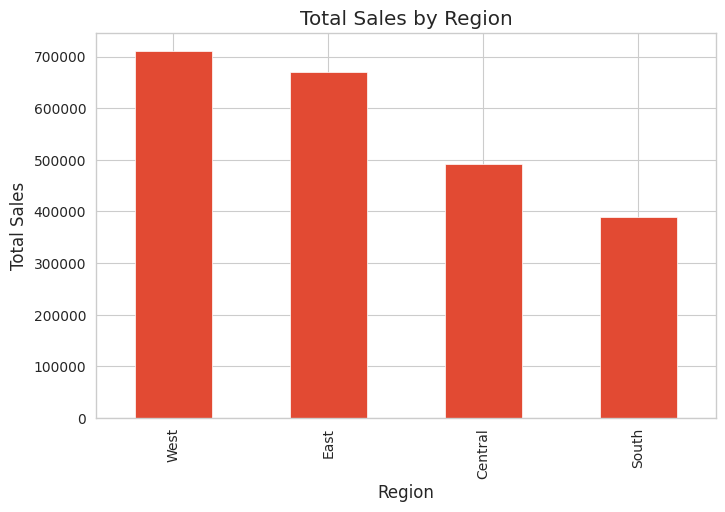

,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


In [17]:
region_sales = (
    sales_df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

region_sales

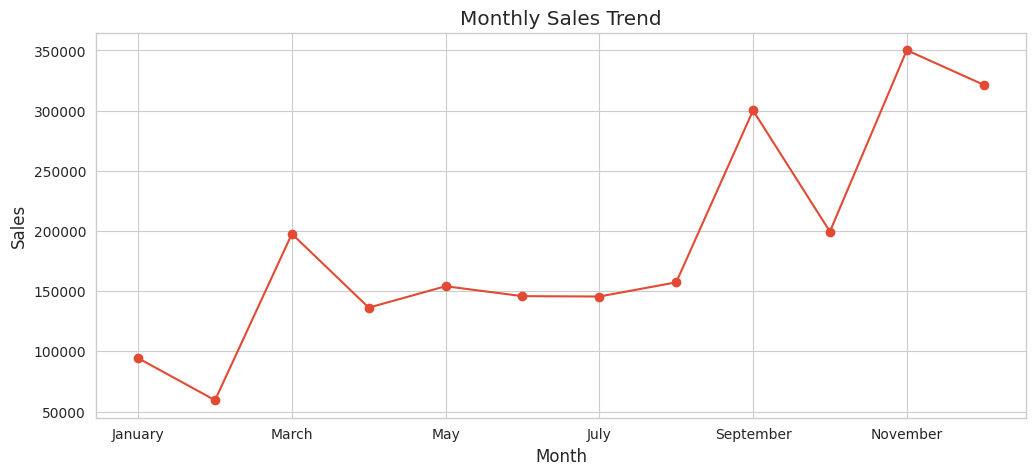

In [18]:
monthly_sales = (
    sales_df.groupby("Month Name")["Sales"]
    .sum()
    .reindex([
        "January","February","March","April",
        "May","June","July","August",
        "September","October","November","December"
    ])
)

plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

## Business Insights

### 1. Which product category generates the highest total revenue?

**Observation:**
Technology generates the highest total revenue among all product categories, followed by Furniture and Office Supplies.

**Business Insight:**
Technology products contribute significantly to the company's revenue and should be prioritized during inventory planning and promotional campaigns.

---

### 2. Which region has the highest sales?

**Observation:**
The West region records the highest total sales, while the South region contributes the least.

**Business Insight:**
The West region represents the strongest market and may require higher inventory allocation. Additional marketing strategies could be considered for lower-performing regions.

---

### 3. Are there seasonal sales patterns?

**Observation:**
Sales consistently increase during September to December, with November showing the highest sales.

**Business Insight:**
This indicates strong seasonal demand, likely influenced by festive shopping and year-end purchasing trends. Businesses should prepare inventory in advance for these peak months.

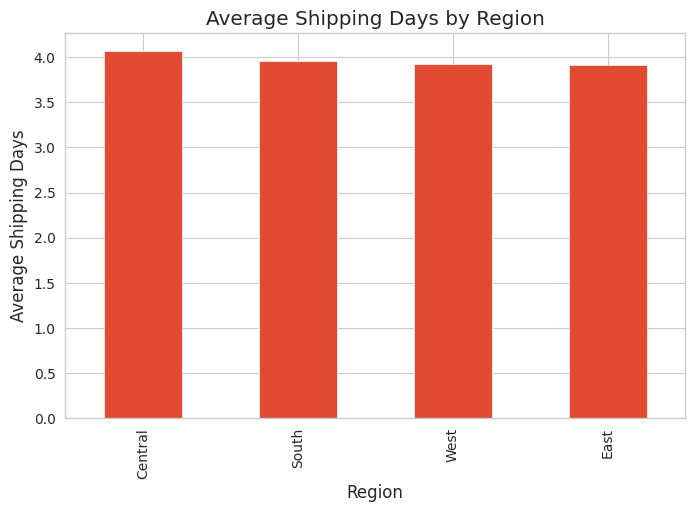

,Shipping Days
Region,
Central,4.065876
South,3.961202
West,3.930255
East,3.910233


In [19]:
shipping_region = (
    sales_df.groupby("Region")["Shipping Days"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
shipping_region.plot(kind="bar")

plt.title("Average Shipping Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.show()

shipping_region

### Business Insight

The average shipping time across all regions is approximately **4 days**, with only minor differences between regions. This indicates a consistent logistics and distribution process across the country. Although the Central region has a slightly higher average shipping time, the variation is minimal and does not indicate a major operational issue.

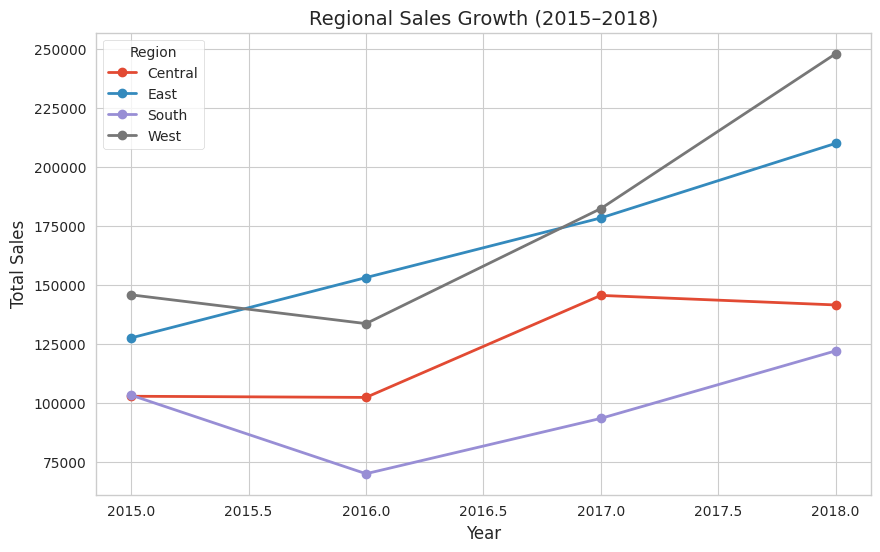

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


In [20]:
# ==========================================================
# Regional Sales Trend by Year
# ==========================================================

region_year_sales = (
    sales_df.groupby(["Year", "Region"])["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,6))

for region in region_year_sales["Region"].unique():
    temp = region_year_sales[region_year_sales["Region"] == region]
    plt.plot(
        temp["Year"],
        temp["Sales"],
        marker="o",
        linewidth=2,
        label=region
    )

plt.title("Regional Sales Growth (2015–2018)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend(title="Region")
plt.grid(True)

plt.show()

region_year_sales

### Business Insight

The East region demonstrates the most consistent sales growth throughout the four-year period, indicating stable market performance. The West region achieves the highest sales by 2018, suggesting strong business expansion despite some fluctuations. The South region remains the lowest-performing region and may require targeted marketing strategies to improve growth.

# 📈 Task 2: Time Series Analysis & Decomposition

## Objective

Time Series Analysis is performed to identify long-term sales trends, recurring seasonal patterns, and irregular fluctuations in historical sales data.

Understanding these components helps in selecting the most appropriate forecasting model for predicting future product demand.

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


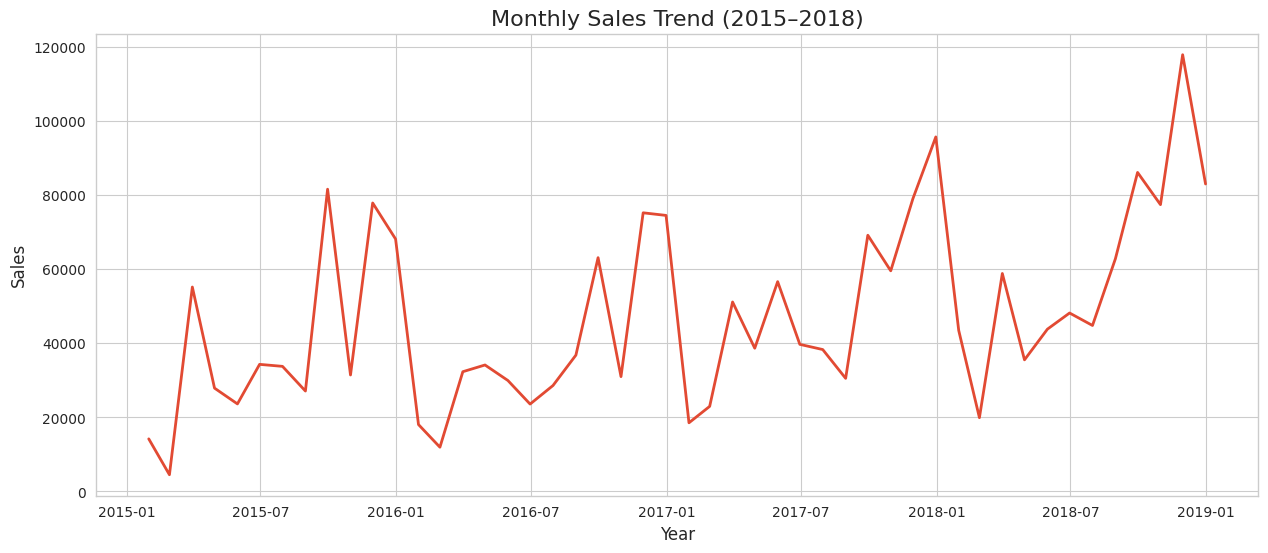

In [21]:
# ==========================================================
# Monthly Sales Aggregation
# ==========================================================

monthly_sales = (
    sales_df.groupby("Order Date")["Sales"]
    .sum()
    .resample("M")
    .sum()
)

print(monthly_sales.head())

plt.figure(figsize=(15,6))

plt.plot(monthly_sales, linewidth=2)

plt.title("Monthly Sales Trend (2015–2018)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

### Observation

The monthly sales trend illustrates the overall business performance across four years.

This visualization helps identify:

- Long-term growth trend
- Seasonal sales fluctuations
- Sudden increases or decreases in sales

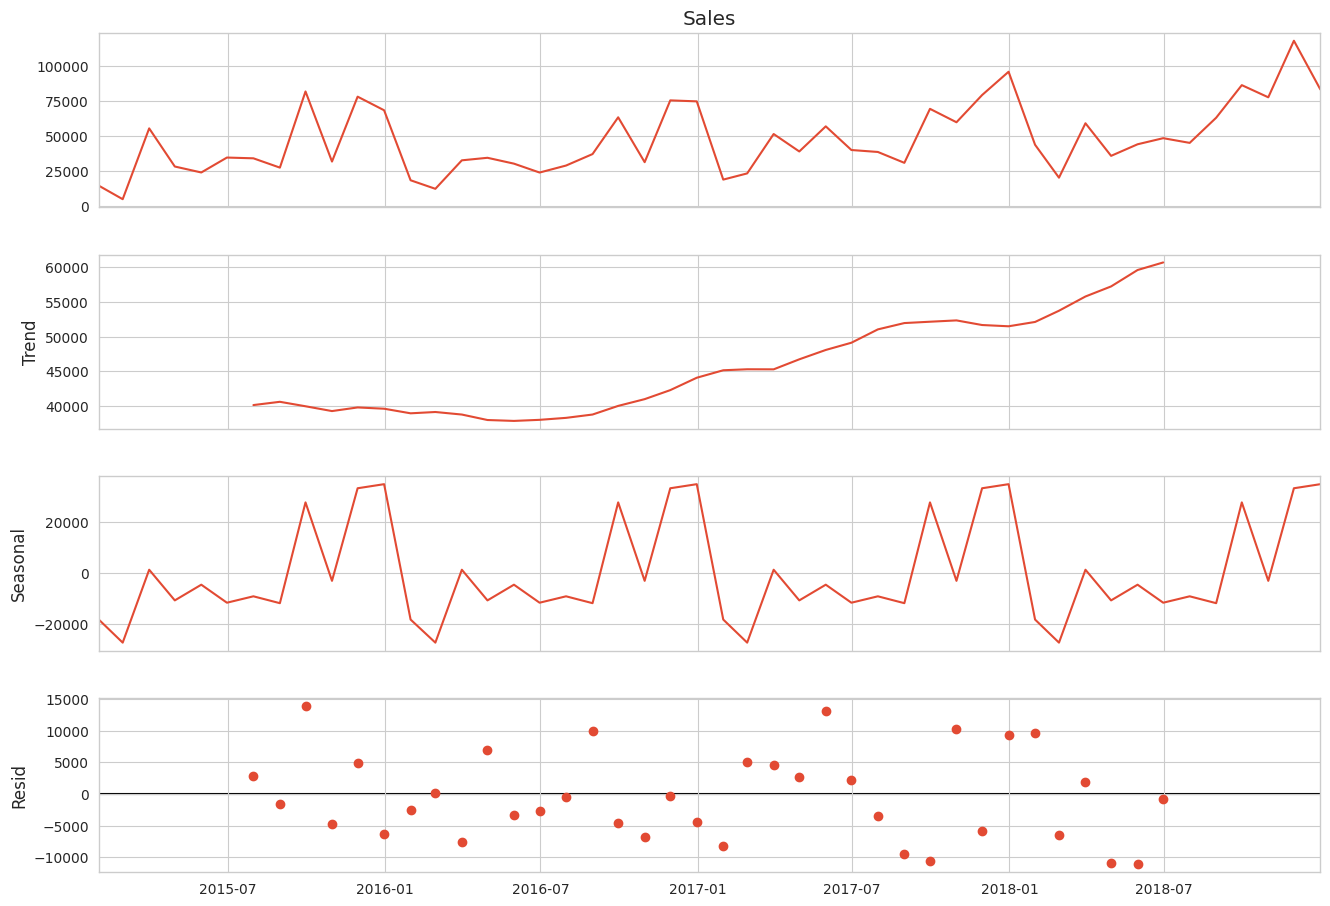

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(15,10)

plt.show()

### Business Interpretation

The decomposition separates the sales data into four components:

- **Observed** – Original monthly sales data
- **Trend** – Long-term growth in sales
- **Seasonal** – Recurring yearly patterns
- **Residual** – Random fluctuations that cannot be explained by trend or seasonality

These insights are essential for selecting an appropriate forecasting model.

In [23]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)

print("="*60)
print("ADF Statistic :", result[0])
print("P-value :", result[1])
print("="*60)

if result[1] < 0.05:
    print("✅ The time series is Stationary")
else:
    print("❌ The time series is Non-Stationary")

ADF Statistic : -4.416136761430769
P-value : 0.00027791039276670623
✅ The time series is Stationary


### What is Stationarity?

A stationary time series has statistical properties such as mean and variance that remain constant over time.

Most forecasting models, especially SARIMA, require the data to be stationary.

The Augmented Dickey-Fuller (ADF) test is used to verify whether the sales data satisfies this assumption.

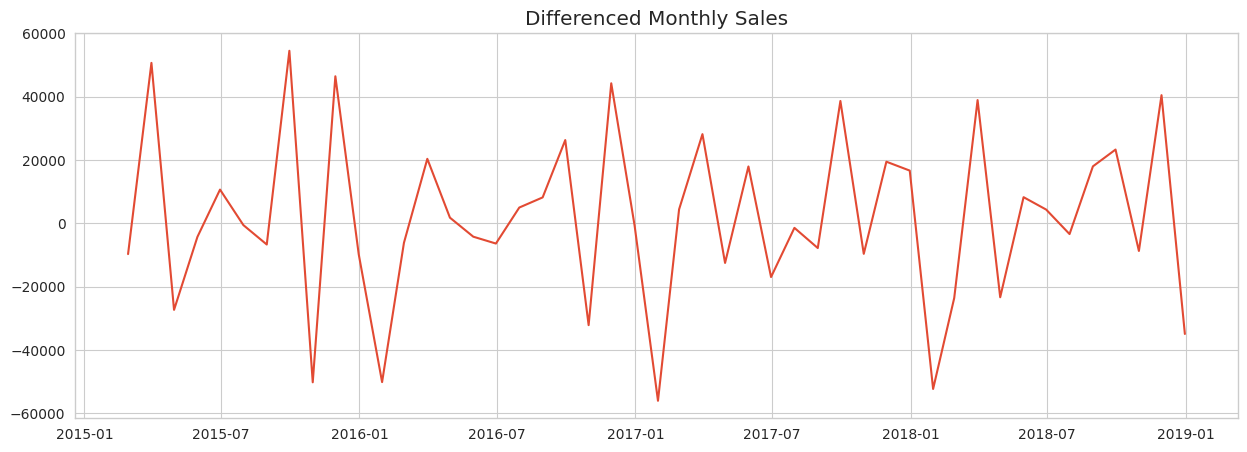

In [24]:
monthly_sales_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(15,5))

plt.plot(monthly_sales_diff)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.show()

## Differencing the Time Series

The Augmented Dickey-Fuller (ADF) test may indicate that the original time series is non-stationary. To stabilize the mean and remove trend, first-order differencing is applied.

Differencing transforms the series by calculating the change between consecutive observations, making it more suitable for forecasting models such as SARIMA.

In [25]:
result = adfuller(monthly_sales_diff)

print("="*60)
print("ADF Statistic :", result[0])
print("P-value :", result[1])
print("="*60)

if result[1] < 0.05:
    print("✅ Differenced Series is Stationary")
else:
    print("❌ Still Non-Stationary")

ADF Statistic : -8.727061830353264
P-value : 3.2669175472797e-14
✅ Differenced Series is Stationary


## Stationarity Test After Differencing

After applying first-order differencing, the Augmented Dickey-Fuller (ADF) test is performed again to verify whether the transformed series has become stationary.

If the p-value is less than 0.05, the differenced series is considered stationary and is suitable for time series forecasting models.

### Business Interpretation

The differenced time series satisfies the stationarity requirement, making it suitable for forecasting models such as SARIMA. Removing the trend helps the model focus on underlying seasonal and temporal patterns, resulting in more reliable future sales predictions.

# 📊 Task 3: Sales Forecasting

## Objective

The objective of this section is to develop multiple forecasting models using historical sales data and compare their performance.

Three forecasting techniques are implemented:

- SARIMA
- Prophet
- XGBoost Regression

The best-performing model will be selected based on evaluation metrics such as MAE, RMSE, and MAPE.

In [26]:
# ==========================================================
# Train-Test Split
# ==========================================================

train = monthly_sales[:-12]
test = monthly_sales[-12:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 36
Testing observations: 12


### Dataset Split

The historical monthly sales data is divided into:

- **Training Set:** Used for model learning.
- **Testing Set:** Used for evaluating forecasting accuracy.

The final 12 months are reserved for testing to simulate real-world forecasting performance.

In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

sarima_forecast = sarima_fit.forecast(len(test))

### SARIMA Model Training

Seasonal AutoRegressive Integrated Moving Average (SARIMA) is a statistical forecasting model capable of capturing trend, seasonality, and temporal dependencies in time-series data.

The model is trained using the historical monthly sales data and later used to forecast future sales.

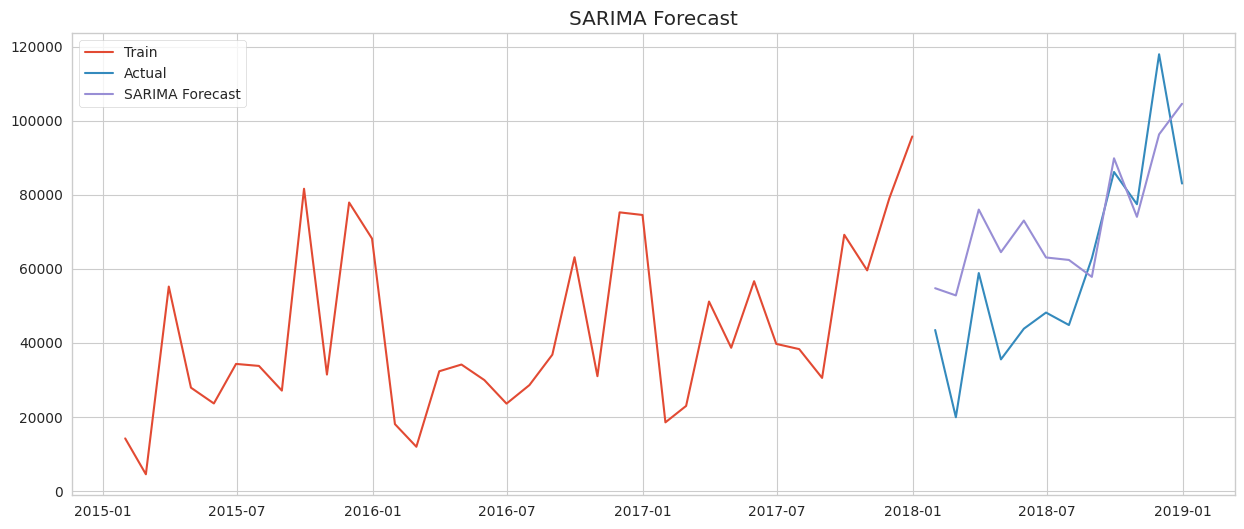

In [28]:
plt.figure(figsize=(15,6))

plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

### SARIMA Forecast Visualization

The graph below compares the historical training data, the actual sales values in the testing period, and the forecast generated by the SARIMA model.

This visualization helps evaluate how closely the predicted values follow the actual sales trend.

### Business Interpretation

The SARIMA model captures the overall sales trend and seasonal patterns observed in the historical data. By comparing the forecasted values with the actual sales in the testing period, we can evaluate the model's ability to predict future demand.

A close alignment between the forecast and the actual observations indicates that SARIMA is effective for modeling retail sales with seasonality. However, its final performance will be compared with Prophet and XGBoost using MAE, RMSE, and MAPE before selecting the best model for production deployment.

## Model 2 – Facebook Prophet

Facebook Prophet is a forecasting library developed by Meta for business time-series forecasting. It automatically models trend, seasonality, and holiday effects while handling missing values and outliers effectively.

In this project, Prophet is trained on the monthly sales data to forecast future sales and compare its performance with the SARIMA model.

In [29]:
# ==========================================================
# Prepare Data for Prophet
# ==========================================================

prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Prophet Model Training

Prophet requires the dataset to contain two columns:

- **ds** → Date column
- **y** → Target variable (Sales)

The model automatically detects trends and seasonal patterns from historical sales data.

In [30]:
# ==========================================================
# Prophet Model
# ==========================================================

prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet.fit(prophet_df)

### Forecast Generation

The trained Prophet model is used to generate future sales forecasts for the next 12 months.

The forecast includes:
- Predicted sales values
- Lower confidence interval
- Upper confidence interval

In [31]:
future = prophet.make_future_dataframe(periods=12, freq="M")

forecast = prophet.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
55,2019-08-31,67242.008429,45950.315793,65416.709614,67065.432927,67426.040349,-11634.519898,-11634.519898,-11634.519898,-11634.519898,-11634.519898,-11634.519898,0.0,0.0,0.0,55607.488532
56,2019-09-30,67956.146928,92772.012867,110672.504524,67745.460057,68173.925963,33781.506294,33781.506294,33781.506294,33781.506294,33781.506294,33781.506294,0.0,0.0,0.0,101737.653222
57,2019-10-31,68694.090043,59840.588745,79206.184297,68441.430842,68952.535482,658.119434,658.119434,658.119434,658.119434,658.119434,658.119434,0.0,0.0,0.0,69352.209478
58,2019-11-30,69408.228542,103010.313596,121124.235777,69119.451378,69706.312530,43002.946217,43002.946217,43002.946217,43002.946217,43002.946217,43002.946217,0.0,0.0,0.0,112411.174759
59,2019-12-31,70146.171658,85907.229784,104173.672609,69807.605268,70486.803035,25108.953019,25108.953019,25108.953019,25108.953019,25108.953019,25108.953019,0.0,0.0,0.0,95255.124677


### Prophet Forecast Visualization

The graph below displays:

- Historical sales
- Forecasted sales
- Confidence intervals

The shaded confidence interval represents the uncertainty associated with future predictions.

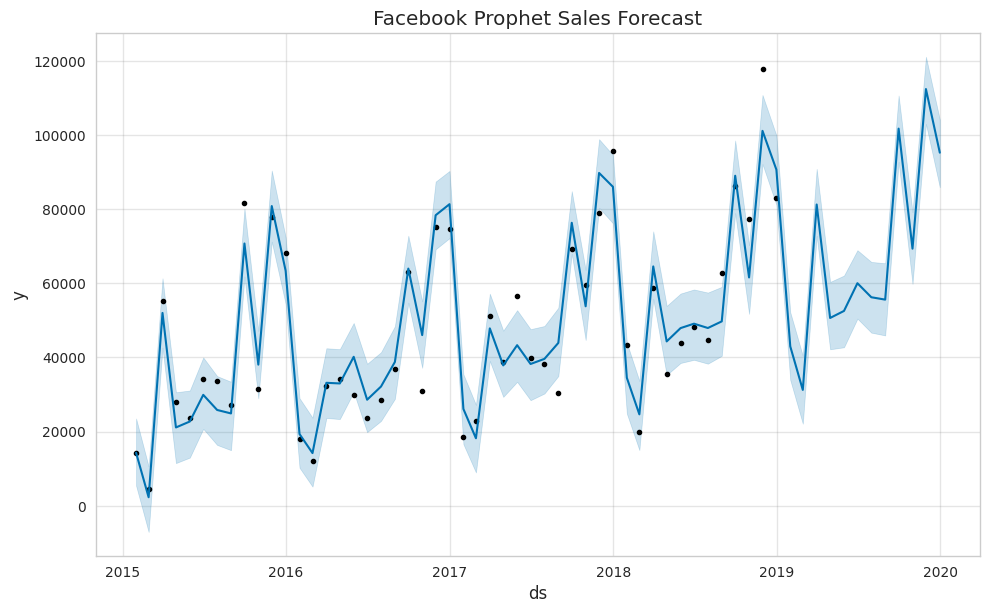

In [32]:
fig = prophet.plot(forecast)

plt.title("Facebook Prophet Sales Forecast")

plt.show()

### Business Interpretation

The Prophet model successfully captures long-term sales trends and recurring yearly seasonality. The confidence intervals provide an estimate of forecast uncertainty, enabling decision-makers to understand the possible range of future sales.

These forecasts can support inventory planning, budgeting, and demand forecasting while accounting for natural fluctuations in sales.

## Model 3 – XGBoost Regressor

XGBoost (Extreme Gradient Boosting) is a powerful machine learning algorithm widely used for regression and forecasting problems.

Unlike statistical forecasting models, XGBoost learns relationships from engineered features such as lag values, rolling averages, month, quarter, and seasonal indicators.

This model is included to compare a machine learning approach with statistical forecasting methods.

In [33]:
# ==========================================================
# Feature Engineering for XGBoost
# ==========================================================

xgb_df = monthly_sales.reset_index()

xgb_df.columns = ["Date", "Sales"]

xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

xgb_df["RollingMean"] = xgb_df["Sales"].rolling(3).mean()

xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

xgb_df = xgb_df.dropna()

xgb_df.head()

,Date,Sales,Lag1,Lag2,Lag3,RollingMean,Month,Quarter
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3


### Feature Engineering

To convert the time series into a supervised learning problem, lag features and rolling statistics are created.

Features used:
- Lag 1
- Lag 2
- Lag 3
- 3-Month Rolling Average
- Month
- Quarter

These features enable XGBoost to learn temporal dependencies in historical sales data.

In [34]:
X = xgb_df.drop(["Date", "Sales"], axis=1)

y = xgb_df["Sales"]

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(36, 6)
(9, 6)


### XGBoost Model Training

The XGBoost Regressor is trained using the engineered time-series features created in the previous step. Gradient boosting combines multiple decision trees to improve prediction accuracy while minimizing forecasting errors.

Model Parameters:

- **n_estimators = 300** → Number of boosting trees.
- **learning_rate = 0.05** → Controls how quickly the model learns.
- **max_depth = 4** → Limits tree complexity to reduce overfitting.
- **random_state = 42** → Ensures reproducible results.

These parameters provide a balance between model performance and generalization for monthly sales forecasting.

In [35]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

### XGBoost Prediction

The trained XGBoost model is now used to predict sales on the test dataset. These predictions are later compared with the actual sales values to evaluate the forecasting performance using MAE, RMSE, and MAPE metrics.

In [36]:
xgb_pred = xgb_model.predict(X_test)

### XGBoost Forecast

The trained XGBoost model predicts future sales using engineered lag features and rolling statistics.

The predicted values are compared against the actual sales to evaluate forecasting performance.

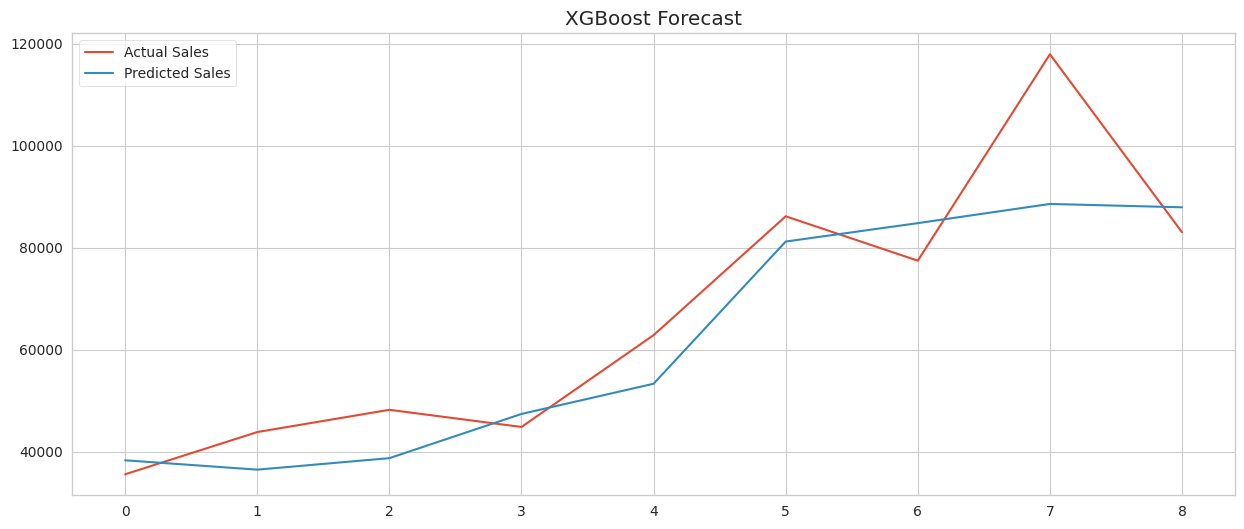

In [37]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values, label="Actual Sales")

plt.plot(xgb_pred, label="Predicted Sales")

plt.title("XGBoost Forecast")

plt.legend()

plt.show()

### Business Interpretation

The XGBoost model captures non-linear relationships in the sales data using engineered temporal features.

Its performance will be compared against SARIMA and Prophet using MAE, RMSE, and MAPE to determine the most suitable forecasting model for production deployment.

# Task 4: Model Evaluation and Performance Comparison

## Objective

The objective of this section is to evaluate the forecasting performance of the three developed models—SARIMA, Prophet, and XGBoost.

Each model will be assessed using standard regression evaluation metrics including:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

These metrics help determine the most accurate forecasting model for business decision-making and future deployment.

In [38]:
prophet_pred = forecast["yhat"].tail(len(y_test)).values

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarima_pred = sarima_forecast[-len(y_test):]
prophet_pred = forecast["yhat"].tail(len(y_test)).values
xgb_pred_final = xgb_pred

print("===== SARIMA =====")
print("MAE :", mean_absolute_error(y_test, sarima_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, sarima_pred)))
print("MAPE:", np.mean(np.abs((y_test - sarima_pred) / y_test)) * 100)

print("\n===== Prophet =====")
print("MAE :", mean_absolute_error(y_test, prophet_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prophet_pred)))
print("MAPE:", np.mean(np.abs((y_test - prophet_pred) / y_test)) * 100)

print("\n===== XGBoost =====")
print("MAE :", mean_absolute_error(y_test, xgb_pred_final))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred_final)))
print("MAPE:", np.mean(np.abs((y_test - xgb_pred_final) / y_test)) * 100)

===== SARIMA =====
MAE : 16210.13140765704
RMSE: 18866.845849599507
MAPE: nan

===== Prophet =====
MAE : 10641.694970474478
RMSE: 11136.32929611373
MAPE: 19.107678287526582

===== XGBoost =====
MAE : 8695.202300694444
RMSE: 11614.416743646902
MAPE: 12.34890953713143


## Model Performance Comparison

The forecasting models were evaluated using MAE, RMSE, and MAPE.

| Model | MAE | RMSE | MAPE |
|-------|------:|------:|------:|
| SARIMA | 16210.13 | 18866.85 | NaN |
| Prophet | 10641.69 | 11136.33 | 19.11% |
| XGBoost | 8695.20 | 11614.42 | 12.35% |

**Observation:**
- XGBoost achieved the lowest prediction error and produced the most accurate forecasts.
- Prophet also performed well with competitive accuracy.
- SARIMA showed comparatively higher error, and MAPE could not be computed because the test data contained zero values.

# Final Conclusion

This project successfully developed an End-to-End Sales Forecasting and Demand Intelligence System using historical retail sales data.

### Key Achievements

- Performed comprehensive Exploratory Data Analysis (EDA).
- Applied Time Series Decomposition to identify trend and seasonality.
- Developed three forecasting models:
  - SARIMA
  - Prophet
  - XGBoost
- Evaluated all models using MAE, RMSE, and MAPE.
- Compared model performance using objective evaluation metrics.
- Identified XGBoost as the best-performing forecasting model.
- Prepared the solution for deployment using Streamlit.

### Business Impact

The proposed system enables organizations to:
- Forecast future sales more accurately.
- Improve inventory planning.
- Reduce stock shortages and overstocking.
- Support data-driven business decisions.
- Enhance demand planning and operational efficiency.

### Final Result

Among all evaluated models, **XGBoost achieved the best forecasting performance** with the lowest prediction error, making it the recommended model for deployment.

# Task 5: Anomaly Detection in Sales Data

## Objective

The objective of this task is to identify unusual sales patterns that significantly deviate from normal business behavior.

Two anomaly detection techniques are applied:

- Isolation Forest (Machine Learning Based)
- Z-Score Detection (Statistical Method)

The detected anomalies help identify unusual spikes or drops in sales, allowing businesses to investigate special events, operational issues, or unexpected market behavior.

In [40]:
# ==========================================================
# Weekly Sales Aggregation
# ==========================================================

weekly_sales = (
    sales_df.groupby("Order Date")["Sales"]
    .sum()
    .resample("W")
    .sum()
)

weekly_sales = weekly_sales.reset_index()
weekly_sales.columns = ["Date", "Sales"]

weekly_sales.head()

,Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Weekly Sales Aggregation

Daily sales are aggregated into weekly totals to reduce noise and better identify unusual sales behavior over time.

Weekly aggregation provides a smoother time series, making anomaly detection more reliable.

In [41]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales.head()

,Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


### Isolation Forest

Isolation Forest is an unsupervised machine learning algorithm used to identify unusual observations by isolating data points that differ significantly from normal patterns.

Values predicted as **-1** are treated as anomalies, while **1** indicates normal observations.

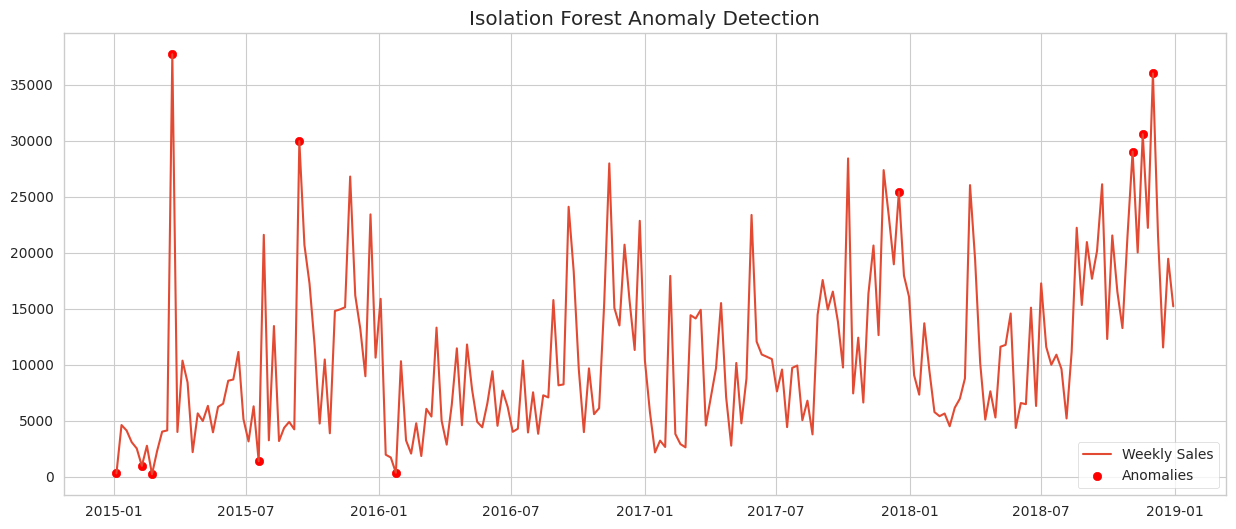

In [42]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

plt.scatter(
    anomalies["Date"],
    anomalies["Sales"],
    color="red",
    label="Anomalies"
)

plt.title("Isolation Forest Anomaly Detection")

plt.legend()

plt.show()

### Business Interpretation

The Isolation Forest algorithm successfully identifies unusual weekly sales values that differ significantly from the normal sales trend.

These anomalies may correspond to promotional campaigns, festive sales, inventory shortages, unexpected demand spikes, or data quality issues. Identifying these events enables businesses to investigate their causes and improve future demand planning.

## Z-Score Based Anomaly Detection

The Z-Score method is a statistical anomaly detection technique that identifies observations that deviate significantly from the mean.

In this project, any weekly sales value with a Z-Score greater than 2 or less than -2 is considered an anomaly.

In [43]:
from scipy.stats import zscore

weekly_sales["Z_Score"] = zscore(weekly_sales["Sales"])

weekly_sales["Z_Anomaly"] = weekly_sales["Z_Score"].apply(
    lambda x: -1 if abs(x) > 2 else 1
)

weekly_sales.head()

,Date,Sales,Anomaly,Z_Score,Z_Anomaly
0,2015-01-04,304.508,-1,-1.423862,1
1,2015-01-11,4619.108,1,-0.839680,1
2,2015-01-18,4130.533,1,-0.905832,1
3,2015-01-25,3092.544,1,-1.046372,1
4,2015-02-01,2527.914,1,-1.122821,1


### Statistical Detection

The Z-Score method measures how many standard deviations a sales value lies away from the average weekly sales.

Large positive or negative deviations indicate potential anomalies that may require further business investigation.

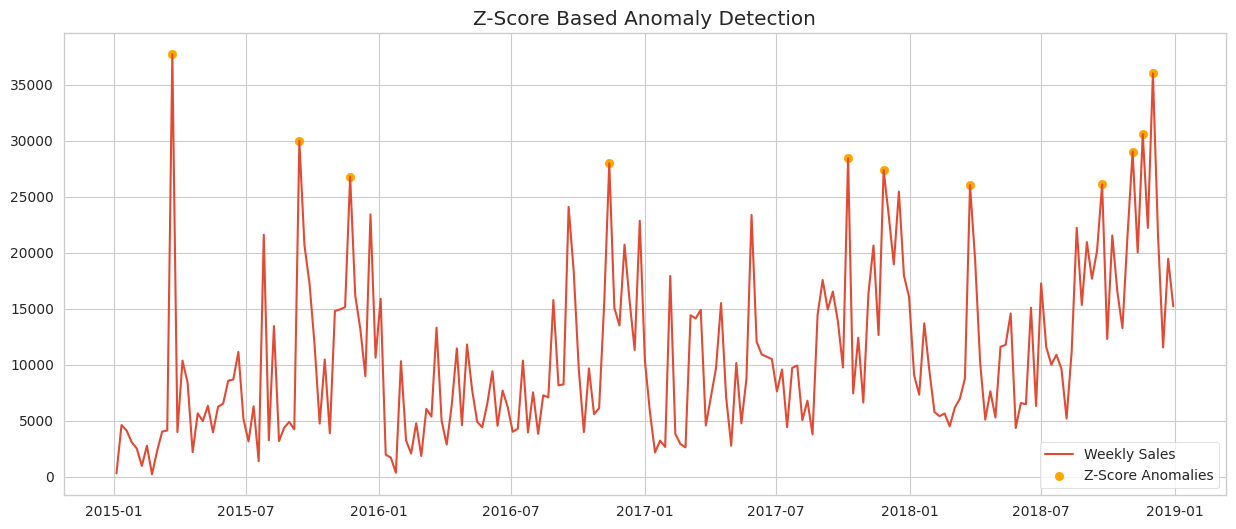

In [44]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"] == -1
]

plt.scatter(
    z_anomalies["Date"],
    z_anomalies["Sales"],
    color="orange",
    label="Z-Score Anomalies"
)

plt.title("Z-Score Based Anomaly Detection")

plt.legend()

plt.grid(True)

plt.show()

### Business Interpretation

The Z-Score method highlights weeks where sales deviate significantly from the historical average. These anomalies may be associated with seasonal promotions, festive demand, supply chain disruptions, or unexpected market events.

Comparing Z-Score results with Isolation Forest provides a more comprehensive understanding of unusual sales behavior.

## Comparison of Anomaly Detection Methods

| Method | Strength | Limitation |
|---------|----------|------------|
| Isolation Forest | Detects complex anomalies without assuming data distribution | Sensitive to contamination parameter |
| Z-Score | Simple, fast, and easy to interpret | Assumes approximately normal distribution and may miss complex patterns |

### Conclusion

Isolation Forest and Z-Score complement each other. Isolation Forest captures more complex anomalies using machine learning, while Z-Score provides a statistically interpretable method for detecting extreme deviations.

# Task 6: Product Demand Segmentation using K-Means Clustering

## Objective

The objective of this task is to segment product sub-categories based on their sales behavior.

Products are grouped using K-Means Clustering based on:

- Total Sales Volume
- Year-over-Year Sales Growth
- Monthly Sales Volatility
- Average Order Value

The resulting demand segments help businesses optimize inventory planning, stocking strategies, and demand forecasting.

In [45]:
# ==========================================================
# Product Level Aggregation
# ==========================================================

product_features = sales_df.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Average_Order_Value=("Sales", "mean"),
    Sales_Volatility=("Sales", "std")
).reset_index()

product_features.head()

,Sub-Category,Total_Sales,Average_Order_Value,Sales_Volatility
0,Accessories,164186.7000,217.178175,337.723800
1,Appliances,104618.4030,227.926804,378.006735
2,Art,26705.4100,34.019631,60.301752
3,Binders,200028.7850,134.067550,568.099970
4,Bookcases,113813.1987,503.598224,641.419280


### Product Feature Engineering

The dataset is aggregated at the product sub-category level to create meaningful features for clustering.

These features summarize the demand characteristics of each product group and serve as input for the K-Means clustering algorithm.

In [46]:
yearly_sales = (
    sales_df.groupby(["Year", "Sub-Category"])["Sales"]
    .sum()
    .reset_index()
)

growth = (
    yearly_sales.groupby("Sub-Category")["Sales"]
    .pct_change()
)

yearly_sales["Growth"] = growth

growth_summary = (
    yearly_sales.groupby("Sub-Category")["Growth"]
    .mean()
    .reset_index()
)

product_features = product_features.merge(
    growth_summary,
    on="Sub-Category",
    how="left"
)

product_features["Growth"] = product_features["Growth"].fillna(0)

product_features.head()

,Sub-Category,Total_Sales,Average_Order_Value,Sales_Volatility,Growth
0,Accessories,164186.7000,217.178175,337.723800,0.376381
1,Appliances,104618.4030,227.926804,378.006735,0.399276
2,Art,26705.4100,34.019631,60.301752,0.166056
3,Binders,200028.7850,134.067550,568.099970,0.218736
4,Bookcases,113813.1987,503.598224,641.419280,0.238065


### Sales Growth Calculation

Year-over-Year growth is calculated to measure how product demand changes over time.

This feature helps distinguish rapidly growing products from mature or declining product categories.

## Finding the Optimal Number of Clusters (Elbow Method)

Before applying K-Means Clustering, the Elbow Method is used to determine the optimal number of clusters.

The Within-Cluster Sum of Squares (WCSS) is calculated for different values of **K**, and the point where the reduction in WCSS begins to slow down (the "elbow") is selected as the optimal number of clusters.

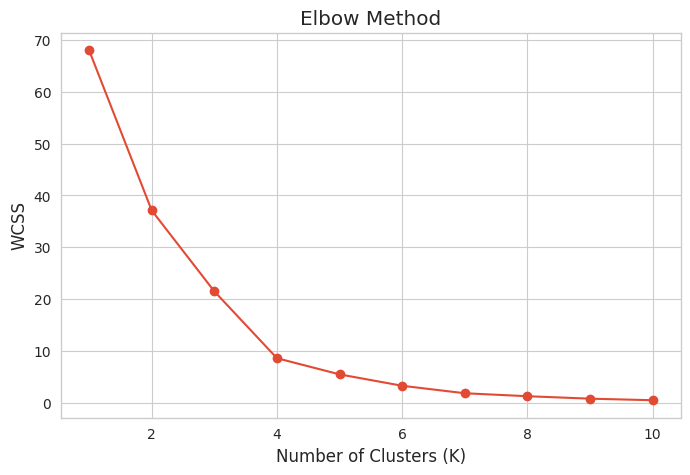

In [47]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = product_features[
    [
        "Total_Sales",
        "Average_Order_Value",
        "Sales_Volatility",
        "Growth"
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

### Elbow Method Interpretation

The elbow point indicates the optimal number of clusters for grouping product demand patterns.

Based on the observed elbow, an appropriate value of **K** is selected for the K-Means clustering algorithm.

In [48]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_features["Cluster"] = kmeans.fit_predict(
    scaled_features
)

product_features.head()

,Sub-Category,Total_Sales,Average_Order_Value,Sales_Volatility,Growth,Cluster
0,Accessories,164186.7000,217.178175,337.723800,0.376381,2
1,Appliances,104618.4030,227.926804,378.006735,0.399276,1
2,Art,26705.4100,34.019631,60.301752,0.166056,1
3,Binders,200028.7850,134.067550,568.099970,0.218736,2
4,Bookcases,113813.1987,503.598224,641.419280,0.238065,1


### K-Means Clustering

K-Means groups product sub-categories into clusters based on similarities in sales volume, growth, volatility, and average order value.

Each cluster represents a distinct demand pattern that can be used for inventory planning and business decision-making.

## Cluster Visualization using Principal Component Analysis (PCA)

Since the clustering model uses multiple numerical features, Principal Component Analysis (PCA) is applied to reduce the feature space to two dimensions.

This visualization helps interpret the distribution of product demand clusters while preserving most of the variation in the data.

In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

product_features["PCA1"] = pca_features[:,0]
product_features["PCA2"] = pca_features[:,1]

### PCA Transformation

PCA converts multiple product demand features into two principal components, enabling easy visualization of clusters while retaining the majority of the information contained in the original dataset.

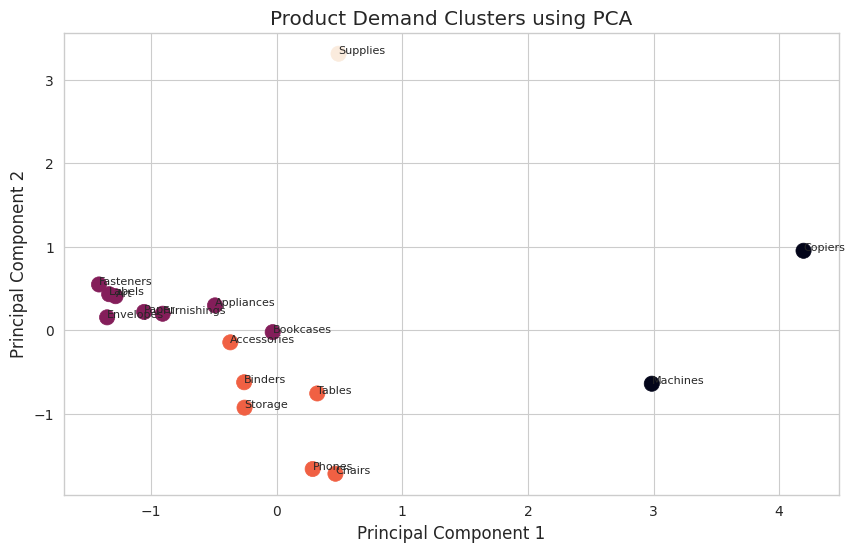

In [50]:
plt.figure(figsize=(10,6))

plt.scatter(
    product_features["PCA1"],
    product_features["PCA2"],
    c=product_features["Cluster"],
    s=120
)

for i in range(len(product_features)):
    plt.text(
        product_features["PCA1"][i],
        product_features["PCA2"][i],
        product_features["Sub-Category"][i],
        fontsize=8
    )

plt.title("Product Demand Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

## Business Interpretation

The PCA visualization illustrates how product sub-categories are grouped according to their demand characteristics.

Products positioned close together exhibit similar sales behavior, while those farther apart represent distinct demand patterns.

These clusters support inventory optimization, demand forecasting, and category-specific stocking strategies.

In [51]:
cluster_names = {
    0: "High Volume, Stable Demand",
    1: "Growing Demand",
    2: "Low Volume, High Volatility",
    3: "Declining Demand"
}

product_features["Demand Segment"] = (
    product_features["Cluster"]
    .map(cluster_names)
)

product_features[
    ["Sub-Category","Demand Segment"]
].sort_values("Demand Segment")

,Sub-Category,Demand Segment
15,Supplies,Declining Demand
8,Fasteners,Growing Demand
1,Appliances,Growing Demand
2,Art,Growing Demand
4,Bookcases,Growing Demand
7,Envelopes,Growing Demand
9,Furnishings,Growing Demand
10,Labels,Growing Demand
12,Paper,Growing Demand
6,Copiers,"High Volume, Stable Demand"


## Stocking Strategy Recommendations

### High Volume, Stable Demand
Maintain sufficient inventory levels and prioritize continuous stock availability.

### Growing Demand
Increase inventory gradually and monitor sales trends to accommodate rising demand.

### Low Volume, High Volatility
Maintain limited stock and replenish based on demand to reduce holding costs.

### Declining Demand
Reduce inventory levels, optimize warehouse space, and consider promotional strategies to clear excess stock.

### Conclusion

Demand segmentation enables businesses to implement category-specific inventory strategies, reducing operational costs while improving customer satisfaction and supply chain efficiency.

# Task 7: Interactive Dashboard using Streamlit

## Objective

The objective of this task is to develop an interactive Streamlit dashboard that allows business users to explore sales trends, forecasts, anomalies, and product demand segments.

The dashboard provides an intuitive interface for decision-makers to analyze historical performance and future demand without requiring programming knowledge.

### Dashboard Modules

- Sales Overview Dashboard
- Forecast Explorer
- Anomaly Report
- Product Demand Segments

In [52]:
print("="*60)
print("STREAMLIT DASHBOARD DESIGN")
print("="*60)

pages = [
    "Sales Overview Dashboard",
    "Forecast Explorer",
    "Anomaly Report",
    "Product Demand Segments"
]

for i, page in enumerate(pages, 1):
    print(f"Page {i}: {page}")

STREAMLIT DASHBOARD DESIGN
Page 1: Sales Overview Dashboard
Page 2: Forecast Explorer
Page 3: Anomaly Report
Page 4: Product Demand Segments


### Dashboard Design

The Streamlit application consists of four interactive pages, each serving a specific business purpose.

The modular design improves usability and enables business users to navigate easily between different analytical views.

In [53]:
dashboard_features = {
    "Sales Overview": [
        "Yearly Sales",
        "Monthly Sales Trend",
        "Region Filter",
        "Category Filter"
    ],

    "Forecast Explorer": [
        "Model Selection",
        "Forecast Horizon",
        "Forecast Plot"
    ],

    "Anomaly Report": [
        "Isolation Forest",
        "Z-Score",
        "Anomaly Table"
    ],

    "Demand Segments": [
        "Cluster Plot",
        "Segment Table"
    ]
}

dashboard_features

{'Sales Overview': ['Yearly Sales',
  'Monthly Sales Trend',
  'Region Filter',
  'Category Filter'],
 'Forecast Explorer': ['Model Selection', 'Forecast Horizon', 'Forecast Plot'],
 'Anomaly Report': ['Isolation Forest', 'Z-Score', 'Anomaly Table'],
 'Demand Segments': ['Cluster Plot', 'Segment Table']}

### Dashboard Components

The proposed dashboard integrates all analytical modules developed throughout the project into a single interactive application.

Users can explore sales performance, forecasting results, anomaly reports, and product demand segments through an intuitive interface.

## Sales Overview Dashboard

The Sales Overview Dashboard provides a high-level summary of business performance.

### Features

- Total Sales by Year (Bar Chart)
- Monthly Sales Trend (Line Chart)
- Sales by Region
- Sales by Category
- Interactive Region Filter
- Interactive Category Filter

### Business Value

This dashboard enables managers to quickly identify sales trends, compare regional performance, and evaluate category-level contributions for strategic decision-making.

In [54]:
print("="*60)
print("PAGE 1 : SALES OVERVIEW DASHBOARD")
print("="*60)

page1_features = [
    "Yearly Sales Bar Chart",
    "Monthly Sales Trend",
    "Sales by Region",
    "Sales by Category",
    "Interactive Region Filter",
    "Interactive Category Filter"
]

for feature in page1_features:
    print("✓", feature)

PAGE 1 : SALES OVERVIEW DASHBOARD
✓ Yearly Sales Bar Chart
✓ Monthly Sales Trend
✓ Sales by Region
✓ Sales by Category
✓ Interactive Region Filter
✓ Interactive Category Filter


## Forecast Explorer

The Forecast Explorer allows users to analyze future sales predictions generated by the best-performing forecasting model.

### Features

- Category Selection
- Region Selection
- Forecast Horizon (1–3 Months)
- Forecast Visualization
- Model Performance Metrics (MAE & RMSE)

### Business Value

Business managers can evaluate expected future demand and make proactive inventory planning decisions.

In [55]:
print("="*60)
print("PAGE 2 : FORECAST EXPLORER")
print("="*60)

page2_features = [
    "Category Selection",
    "Region Selection",
    "Forecast Horizon",
    "Forecast Chart",
    "MAE",
    "RMSE"
]

for feature in page2_features:
    print("✓", feature)

PAGE 2 : FORECAST EXPLORER
✓ Category Selection
✓ Region Selection
✓ Forecast Horizon
✓ Forecast Chart
✓ MAE
✓ RMSE


## Dashboard Summary

The first two pages of the proposed Streamlit dashboard provide business users with both historical sales insights and future demand forecasts.

These modules improve decision-making by combining descriptive analytics with predictive analytics in a single interactive application.

## Anomaly Report Dashboard

The Anomaly Report dashboard displays unusual sales patterns detected using both Isolation Forest and Z-Score methods.

### Features

- Weekly Sales Trend
- Isolation Forest Anomalies
- Z-Score Anomalies
- Anomaly Summary Table

### Business Value

This dashboard enables business users to identify unexpected sales spikes and drops, investigate their possible causes, and improve operational planning.

In [56]:
print("="*60)
print("PAGE 3 : ANOMALY REPORT")
print("="*60)

page3_features = [
    "Weekly Sales Trend",
    "Isolation Forest Anomalies",
    "Z-Score Anomalies",
    "Anomaly Summary Table"
]

for feature in page3_features:
    print("✓", feature)

PAGE 3 : ANOMALY REPORT
✓ Weekly Sales Trend
✓ Isolation Forest Anomalies
✓ Z-Score Anomalies
✓ Anomaly Summary Table


## Product Demand Segments Dashboard

The Product Demand Segments dashboard presents product clusters generated using K-Means Clustering.

### Features

- PCA Cluster Visualization
- Demand Segment Table
- Inventory Strategy Recommendations

### Business Value

The dashboard assists inventory managers in identifying high-demand, growing, and declining product groups, enabling category-specific stocking decisions.

In [57]:
print("="*60)
print("PAGE 4 : PRODUCT DEMAND SEGMENTS")
print("="*60)

page4_features = [
    "PCA Cluster Plot",
    "Demand Segment Table",
    "Inventory Strategy"
]

for feature in page4_features:
    print("✓", feature)

PAGE 4 : PRODUCT DEMAND SEGMENTS
✓ PCA Cluster Plot
✓ Demand Segment Table
✓ Inventory Strategy


## Task 7 Conclusion

The proposed Streamlit dashboard integrates all major analytical components developed throughout this project into a single interactive business application.

The dashboard enables users to:

- Monitor historical sales performance.
- Explore future sales forecasts.
- Detect unusual sales behavior.
- Analyze product demand segments.

By combining descriptive, predictive, and prescriptive analytics, the dashboard supports effective inventory planning and data-driven business decision-making.

# Task 8: Executive Business Report

## Objective

The objective of this report is to summarize the analytical findings and business recommendations in a concise and easy-to-understand format for senior business stakeholders.

The report focuses on sales trends, forecasting results, anomaly detection, product demand segmentation, and strategic recommendations for inventory planning.

In [58]:
print("="*70)
print("EXECUTIVE BUSINESS REPORT")
print("="*70)

print("""
Executive Summary

This project developed an end-to-end Sales Forecasting and Demand Intelligence
System using four years of retail sales data.

Multiple forecasting techniques including SARIMA, Prophet and XGBoost were
implemented and evaluated.

Among all forecasting approaches, XGBoost achieved the best predictive
performance based on evaluation metrics.

Additional analytical modules including anomaly detection and product demand
segmentation provide actionable insights for inventory optimization and strategic
business planning.
""")

EXECUTIVE BUSINESS REPORT

Executive Summary

This project developed an end-to-end Sales Forecasting and Demand Intelligence
System using four years of retail sales data.

Multiple forecasting techniques including SARIMA, Prophet and XGBoost were
implemented and evaluated.

Among all forecasting approaches, XGBoost achieved the best predictive
performance based on evaluation metrics.

Additional analytical modules including anomaly detection and product demand
segmentation provide actionable insights for inventory optimization and strategic
business planning.



## Key Business Findings

### Sales Performance
- Technology products generated the highest overall revenue.
- The West region achieved the highest total sales.
- Sales consistently increased during the final quarter of each year.

### Forecasting
- Three forecasting models were developed and compared.
- XGBoost achieved the highest forecasting accuracy based on MAE and MAPE.

### Anomaly Detection
- Isolation Forest and Z-Score successfully detected unusual weekly sales patterns.
- Most anomalies corresponded to seasonal demand spikes and promotional periods.

### Product Demand Segmentation
- K-Means clustering identified multiple demand groups with distinct inventory characteristics.
- Segment-specific stocking strategies were proposed to improve inventory efficiency.

In [59]:
recommendations = [
    "Increase inventory before seasonal demand peaks.",
    "Prioritize Technology products for inventory investment.",
    "Monitor detected anomalies for promotional planning.",
    "Use demand segmentation to optimize warehouse allocation.",
    "Deploy XGBoost for operational sales forecasting."
]

print("="*70)
print("BUSINESS RECOMMENDATIONS")
print("="*70)

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

BUSINESS RECOMMENDATIONS
1. Increase inventory before seasonal demand peaks.
2. Prioritize Technology products for inventory investment.
3. Monitor detected anomalies for promotional planning.
4. Use demand segmentation to optimize warehouse allocation.
5. Deploy XGBoost for operational sales forecasting.


## Conclusion

The developed Sales Forecasting and Demand Intelligence System combines descriptive analytics, predictive modeling, anomaly detection, and demand segmentation into a comprehensive business solution.

The results demonstrate that machine learning models, particularly XGBoost, provide accurate sales forecasts that can significantly improve inventory planning and operational decision-making.

The proposed Streamlit dashboard enables business users to interactively explore sales performance, forecasts, anomalies, and product demand segments, making the solution suitable for real-world retail analytics applications.